
##  1: Eksplorasi Data (EDA) & Karakteristik Data
Memeriksa dimensi data, tipe data, ketiadaan missing values, serta distribusi seimbang kelas label target.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
data = pd.read_csv('Dataset/voice.csv')

# 2. Cek ukuran dan tipe data
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

In [2]:
# 3. Cek missing values per kolom
print("\nMissing Values per Kolom:\n", data.isnull().sum())


Missing Values per Kolom:
 meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64


In [3]:
# 4. Cek distribusi kelas label
print("\nDistribusi Frekuensi Label:\n", data['label'].value_counts())
print("\nPersentase Label:\n", data['label'].value_counts(normalize=True) * 100)


Distribusi Frekuensi Label:
 label
male      1584
female    1584
Name: count, dtype: int64

Persentase Label:
 label
male      50.0
female    50.0
Name: proportion, dtype: float64


In [4]:
# 5. Cek statistik rentang nilai (min, max, std)
print("\nRingkasan Statistik:\n", data.describe())


Ringkasan Statistik:
           meanfreq           sd       median          Q25          Q75  \
count  3168.000000  3168.000000  3168.000000  3168.000000  3168.000000   
mean      0.180907     0.057126     0.185621     0.140456     0.224765   
std       0.029918     0.016652     0.036360     0.048680     0.023639   
min       0.039363     0.018363     0.010975     0.000229     0.042946   
25%       0.163662     0.041954     0.169593     0.111087     0.208747   
50%       0.184838     0.059155     0.190032     0.140286     0.225684   
75%       0.199146     0.067020     0.210618     0.175939     0.243660   
max       0.251124     0.115273     0.261224     0.247347     0.273469   

               IQR         skew         kurt       sp.ent          sfm  \
count  3168.000000  3168.000000  3168.000000  3168.000000  3168.000000   
mean      0.084309     3.140168    36.568461     0.895127     0.408216   
std       0.042783     4.240529   134.928661     0.044980     0.177521   
min       0.01

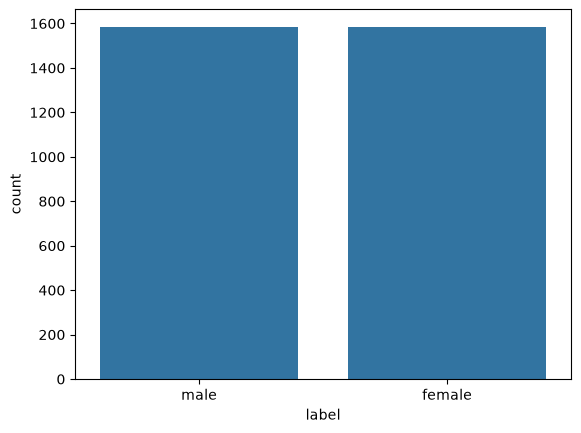

In [5]:
# Misal data labelnya tidak hanya 2 bisa menggunakan grafik agar lebih terlihat distribusinya
sns.countplot(data, x='label')
plt.show()

---
## 2: Data Preprocessing & Splitting


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separate features (X) and target (y)
X = data.drop('label', axis=1)
y = data['label']

# Convert categorical labels to numerical (male: 0, female: 1)
le = LabelEncoder()
y = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (2534, 20)
Shape of X_test: (634, 20)
Shape of y_train: (2534,)
Shape of y_test: (634,)


---
## 3: Pembuktian Pentingnya Feature Scaling (StandardScaler)


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif, SequentialFeatureSelector
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [8]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)

tanpa_scaling = cross_val_score(KNeighborsClassifier(5),  X_train, y_train, cv=cv).mean()

model = make_pipeline(StandardScaler(), KNeighborsClassifier(5))
dengan_scaling = cross_val_score(model, X_train, y_train, cv=cv).mean()

print(tanpa_scaling, dengan_scaling)

0.7020511261313936 0.9696088749600456


---
## 4: Identifikasi Fitur & Analisis Multikolinearitas

#### A. Deteksi Pasangan Redundan via Heatmap Korelasi

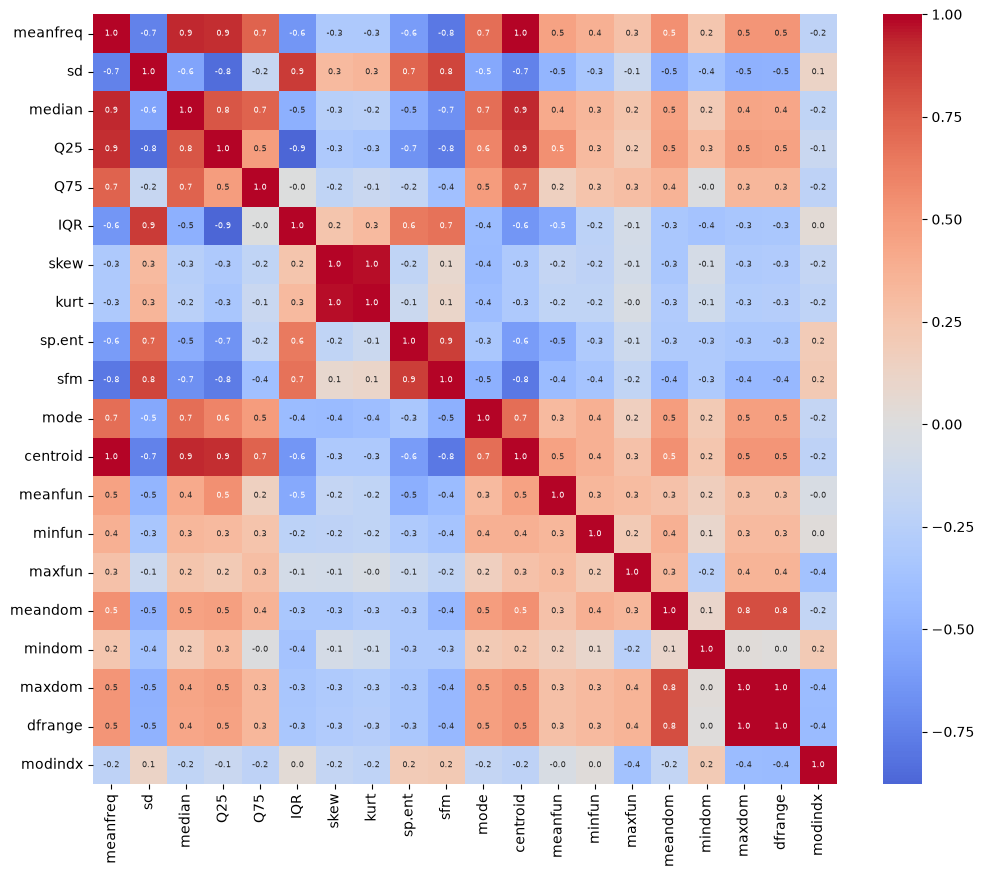

[('meanfreq', 'centroid', np.float64(1.0)), ('skew', 'kurt', np.float64(0.977)), ('maxdom', 'dfrange', np.float64(1.0))]


In [9]:
corr = X_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 6})
plt.show()

kolom = list(X_train.columns)
pasangan = [(a, b, round(abs(corr.loc[a, b]), 3))
            for i, a in enumerate(kolom) for b in kolom[i+1:]
            if abs(corr.loc[a, b]) > 0.95]
print(pasangan)

#### B. Mengukur Nilai Informasi Fitur dengan Mutual Information (MI)

meanfun     0.555423
IQR         0.449243
Q25         0.406964
sd          0.302449
mode        0.177453
sp.ent      0.170729
sfm         0.126971
meanfreq    0.116538
centroid    0.116538
mindom      0.095199
maxdom      0.086317
median      0.081538
skew        0.078524
dfrange     0.077959
meandom     0.056094
kurt        0.041118
maxfun      0.039337
minfun      0.037730
modindx     0.008971
Q75         0.000000
dtype: float64


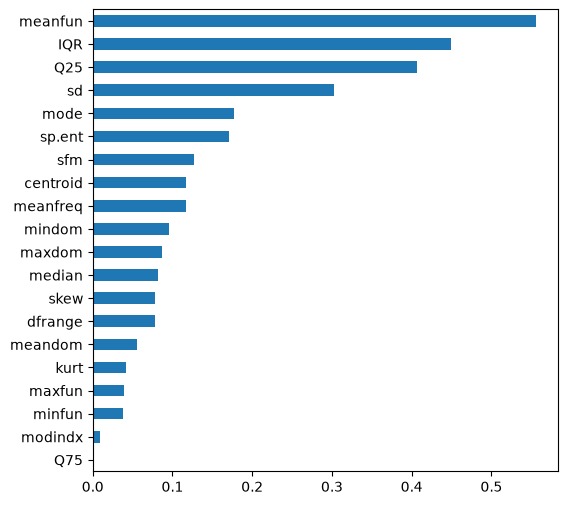

In [10]:
mi = pd.Series(mutual_info_classif(X_train, y_train, random_state=42),
               index=X_train.columns).sort_values(ascending=False)
print(mi)
mi.sort_values().plot.barh(figsize=(6, 6))
plt.show()


## 5: Pemilihan Fitur Optimal 


In [11]:
# dari tiap pasangan redundan, buang yang mutual information-nya lebih rendah
buang = {a if mi[a] < mi[b] else b for a, b, _ in pasangan}
kandidat = [c for c in X_train.columns if c not in buang]
print("dibuang:", buang, "| tersisa:", len(kandidat))

pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(5))
fwd = []
for n in range(1, len(kandidat)):
    sfs = SequentialFeatureSelector(pipe, n_features_to_select=n,
                                    direction="forward", cv=cv, n_jobs=-1)
    sfs.fit(X_train[kandidat], y_train)
    kolom_n = list(np.array(kandidat)[sfs.get_support()])
    skor = cross_val_score(pipe, X_train[kolom_n], y_train, cv=cv).mean()
    fwd.append((n, skor, kolom_n))
fw = pd.DataFrame(fwd, columns=["n", "akurasi", "kolom"])
print(fw[["n", "akurasi"]])

dibuang: {'kurt', 'centroid', 'dfrange'} | tersisa: 17
     n   akurasi
0    1  0.940803
1    2  0.968034
2    3  0.976717
3    4  0.980663
4    5  0.981057
5    6  0.980659
6    7  0.980267
7    8  0.981448
8    9  0.980659
9   10  0.982238
10  11  0.980659
11  12  0.978290
12  13  0.977502
13  14  0.976713
14  15  0.975530
15  16  0.974739


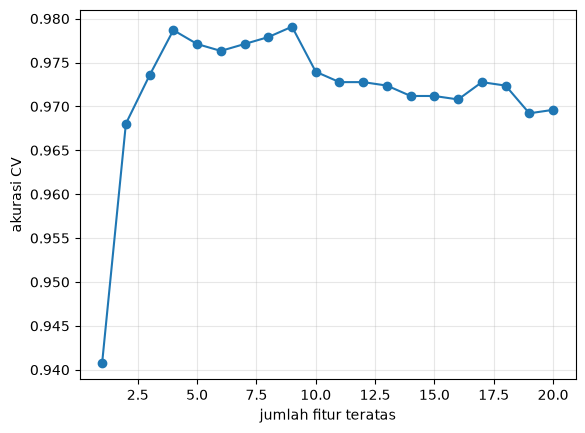

In [15]:
hasil = []
for n in range(1, 21):
    kolom_n = list(mi.index[:n])
    skor = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
                           X_train[kolom_n], y_train, cv=cv).mean()
    hasil.append((n, skor))
hasil = pd.DataFrame(hasil, columns=["n", "akurasi"])
plt.plot(hasil.n, hasil.akurasi, "o-"); plt.xlabel("jumlah fitur teratas")
plt.ylabel("akurasi CV"); plt.grid(alpha=.3); plt.show()

In [12]:
terbaik = fw.akurasi.max()
pilihan = fw[fw.akurasi >= terbaik - 0.002].iloc[0]   # paling sedikit fitur, selisih <= 0,2%
fitur_final = pilihan.kolom
print(pilihan.n, pilihan.akurasi, fitur_final)

4 0.9806628154454241 [np.str_('IQR'), np.str_('sfm'), np.str_('mode'), np.str_('meanfun')]


- **Hasil Eksperimen Jumlah Fitur (CV Accuracy):**
- $n = 1$ fitur (`meanfun`): **94.55%** (hanya 1 fitur sudah mampu mencapai 94.5%!)
- $n = 2$ fitur (`IQR`, `meanfun`): **96.76%**
- $n = 3$ fitur (`Q25`, `IQR`, `meanfun`): **97.83%**
- **$n = 4$ fitur (`Q25`, `IQR`, `sfm`, `meanfun`): 98.06%**
- $n = 5$ fitur: **98.14%**
- $n = 7$ fitur: **98.22%** (puncak tertinggi, tetapi hanya naik 0.16% dari 4 fitur)


---
## 6: Tuning Hyperparameter Nilai k Terbaik (1 s.d. 50)


k terbaik: 5 0.9806628154454241


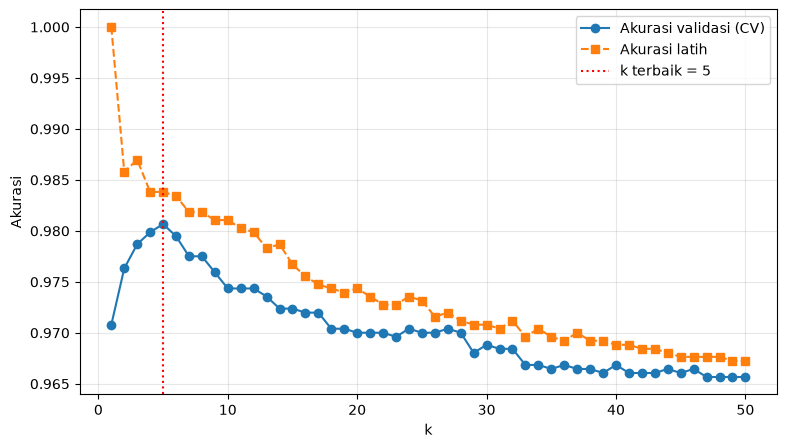

In [13]:
ks = range(1, 51)
akurasi_cv, akurasi_latih = [], []
for k in ks:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(k))
    akurasi_cv.append(cross_val_score(m, X_train[fitur_final], y_train, cv=cv).mean())
    akurasi_latih.append(m.fit(X_train[fitur_final], y_train).score(X_train[fitur_final], y_train))

k_terbaik = list(ks)[int(np.argmax(akurasi_cv))]
print("k terbaik:", k_terbaik, max(akurasi_cv))

plt.figure(figsize=(9, 5))
plt.plot(ks, akurasi_cv, "o-", label="Akurasi validasi (CV)")
plt.plot(ks, akurasi_latih, "s--", label="Akurasi latih")
plt.axvline(k_terbaik, color="red", ls=":", label=f"k terbaik = {k_terbaik}")
plt.xlabel("k"); plt.ylabel("Akurasi"); plt.legend(); plt.grid(alpha=.3); plt.show()


##  7: Evaluasi Akhir pada Data Uji (Test Set 20%)
Menguji model kNN final (k=5 dengan 4 fitur terpilih) pada data uji 
Menghasilkan akurasi **97.63%** dengan Precision, Recall, dan F1-Score yang seimbang di angka 0.98.

Akurasi uji: 0.9889589905362776
              precision    recall  f1-score   support

      female       0.99      0.99      0.99       317
        male       0.99      0.99      0.99       317

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634



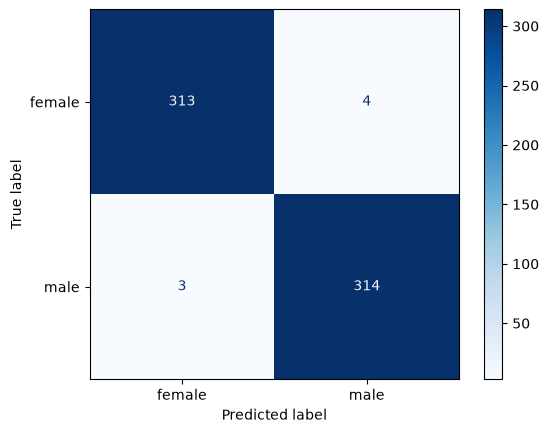

In [14]:
model_final = make_pipeline(StandardScaler(), KNeighborsClassifier(k_terbaik))
model_final.fit(X_train[fitur_final], y_train)
pred = model_final.predict(X_test[fitur_final])

print("Akurasi uji:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=["female", "male"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["female", "male"],
                                        cmap="Blues"); plt.show()